# Wind Generation Forecasting

This notebook develops machine learning models to forecast wind power generation in Germany using weather, temporal, demand, and renewable energy system features.

The target variable is:

- DE_wind_generation_actual

Wind power is one of Germany's most important renewable energy sources and plays a critical role in the country's energy transition. Accurate forecasting of wind generation supports grid operation, renewable integration, and carbon emissions reduction strategies.

The objective of this notebook is to identify the most effective machine learning model for predicting wind generation and to understand the key drivers influencing wind power output.

## Data Preparation and Chronological Train-Test Split

Because wind generation is time-dependent, the dataset is split chronologically rather than randomly. The first 80% of observations are used for training, while the final 20% are reserved for testing.

This approach better reflects a real forecasting scenario, where models are trained on historical data and evaluated on future unseen observations.

In [9]:
import pandas as pd
import numpy as np

# Load model-ready dataset
df = pd.read_csv("../data/processed/model_ready_features.csv")

print("Dataset shape:", df.shape)

# Ensure chronological ordering
df = df.sort_values("utc_timestamp").reset_index(drop=True)

# Define target variable
target_col = "DE_wind_generation_actual"

y = df[target_col]

# Define feature matrix
X = df.drop(
    columns=[
        target_col,
        "DE_LU_price_day_ahead",
        'renewable_generation',
        'renewable_share_pct',
        "utc_timestamp",
        "time"
    ],
    errors="ignore"
)

# Chronological 80/20 split
split_index = int(len(df) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

print("\nTraining set:", X_train.shape)
print("Test set:", X_test.shape)

print("\nMissing values in X:", X.isnull().sum().sum())

Dataset shape: (50232, 31)
Feature matrix shape: (50232, 25)
Target shape: (50232,)

Training set: (40185, 25)
Test set: (10047, 25)

Missing values in X: 0


The dataset was successfully divided into chronological training and test sets. This avoids data leakage from the future into the training process and provides a more realistic evaluation of wind generation forecasting performance.

## Baseline Forecast

Before applying machine learning models, a simple baseline forecast is established.

The baseline predictor uses the mean wind generation observed in the training dataset and predicts this constant value for all observations in the test set.

This benchmark provides a reference point against which the performance of more sophisticated forecasting models can be evaluated.

In [10]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

baseline_prediction = np.full(
    shape=len(y_test),
    fill_value=y_train.mean()
)

baseline_mae = mean_absolute_error(y_test, baseline_prediction)
baseline_rmse = np.sqrt(mean_squared_error(y_test, baseline_prediction))
baseline_r2 = r2_score(y_test, baseline_prediction)

print("Baseline MAE :", round(baseline_mae, 4))
print("Baseline RMSE:", round(baseline_rmse, 4))
print("Baseline R²  :", round(baseline_r2, 4))

Baseline MAE : 8334.1209
Baseline RMSE: 11049.1728
Baseline R²  : -0.1096


## Baseline Model Performance

The baseline model predicts the mean wind generation observed in the training dataset for every observation in the test set.

| Metric | Value |
|----------|----------:|
| MAE | 8334.12 |
| RMSE | 11049.17 |
| R² | -0.1096 |

The baseline model exhibits poor predictive performance, as expected. The negative R² value indicates that simply predicting the mean wind generation performs worse than using the actual average of the test data as a predictor.

These results establish a benchmark against which more sophisticated machine learning models can be evaluated. Any useful forecasting model should significantly reduce prediction errors and achieve a positive R² score relative to this baseline.

## Linear Regression Model

Linear Regression is used as the first machine learning model for wind generation forecasting.

This model assumes a linear relationship between the predictor variables and wind power generation. Although wind generation is influenced by complex meteorological processes, Linear Regression provides a useful benchmark and helps assess whether simple linear relationships are sufficient to explain variations in wind output.

The model is evaluated using:

- Mean Absolute Error (MAE)
- Root Mean Squared Error (RMSE)
- Coefficient of Determination (R²)

Its performance will be compared against the baseline model and more advanced machine learning approaches.

In [11]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Train model
lr_model = LinearRegression()

lr_model.fit(X_train, y_train)

# Predictions
y_pred_lr = lr_model.predict(X_test)

# Metrics
lr_mae = mean_absolute_error(y_test, y_pred_lr)
lr_rmse = np.sqrt(mean_squared_error(y_test, y_pred_lr))
lr_r2 = r2_score(y_test, y_pred_lr)

print("Linear Regression MAE :", round(lr_mae, 4))
print("Linear Regression RMSE:", round(lr_rmse, 4))
print("Linear Regression R²  :", round(lr_r2, 4))

Linear Regression MAE : 4050.6753
Linear Regression RMSE: 5223.4037
Linear Regression R²  : 0.752


## Linear Regression Results

| Metric | Value |
|----------|----------:|
| MAE | 4050.68 |
| RMSE | 5223.40 |
| R² | 0.7520 |

The Linear Regression model substantially outperformed the baseline forecast, reducing both MAE and RMSE by more than 50%.

An R² value of 0.752 indicates that approximately 75% of the variation in wind generation can be explained by the selected predictor variables. This demonstrates that weather, temporal, and energy system features contain significant predictive information regarding wind power output.

Despite this improvement, a considerable portion of the variance remains unexplained, suggesting the presence of nonlinear relationships that cannot be fully captured by a linear model. More advanced machine learning approaches such as Random Forest and XGBoost are therefore evaluated in subsequent sections.

## Random Forest Model

Random Forest is an ensemble machine learning algorithm that combines the predictions of multiple decision trees.

Unlike Linear Regression, Random Forest can model nonlinear relationships and interactions among variables without requiring explicit assumptions about the underlying data distribution. This capability makes it particularly suitable for wind generation forecasting, where meteorological conditions often influence power output in complex ways.

The Random Forest model is trained using the same feature set and chronological train-test split as the previous models. Its performance is evaluated using MAE, RMSE, and R² to determine whether nonlinear modelling improves forecasting accuracy.

In [4]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Train model
rf_model = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

# Predictions
y_pred_rf = rf_model.predict(X_test)

# Metrics
rf_mae = mean_absolute_error(y_test, y_pred_rf)
rf_rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))
rf_r2 = r2_score(y_test, y_pred_rf)

print("Random Forest MAE :", round(rf_mae, 4))
print("Random Forest RMSE:", round(rf_rmse, 4))
print("Random Forest R²  :", round(rf_r2, 4))

Random Forest MAE : 4021.2774
Random Forest RMSE: 5238.7465
Random Forest R²  : 0.7506


## Random Forest Results

| Metric | Value |
|----------|----------:|
| MAE | 4021.28 |
| RMSE | 5238.75 |
| R² | 0.7506 |

The Random Forest model achieved performance comparable to Linear Regression but did not produce a meaningful improvement in predictive accuracy.

While the MAE decreased slightly, both RMSE and R² were marginally worse than those obtained using Linear Regression. This suggests that the current feature set may already capture much of the underlying relationship between the predictors and wind generation through relatively simple patterns.

The results indicate that increasing model complexity does not automatically lead to better forecasting performance. Further improvements may require more informative features rather than a more complex learning algorithm.

The next step is to evaluate XGBoost, a gradient boosting model that often performs better than Random Forest on structured tabular datasets.

## XGBoost Model

XGBoost is a gradient boosting algorithm that sequentially builds decision trees to correct the errors of previous trees.

It is widely regarded as one of the most effective machine learning algorithms for structured tabular datasets and has demonstrated strong performance in numerous energy forecasting applications.

The model is evaluated using the same chronological train-test split and performance metrics as the previous models. The results are compared against the baseline, Linear Regression, and Random Forest models to determine whether gradient boosting provides additional predictive capability for wind generation forecasting.

In [6]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Train model
xgb_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    objective='reg:squarederror',
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(X_train, y_train)

# Predictions
y_pred_xgb = xgb_model.predict(X_test)

# Metrics
xgb_mae = mean_absolute_error(y_test, y_pred_xgb)
xgb_rmse = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
xgb_r2 = r2_score(y_test, y_pred_xgb)

print("XGBoost MAE :", round(xgb_mae, 4))
print("XGBoost RMSE:", round(xgb_rmse, 4))
print("XGBoost R²  :", round(xgb_r2, 4))

XGBoost MAE : 4364.6852
XGBoost RMSE: 5729.3097
XGBoost R²  : 0.7017


## Model Comparison and Initial Observations

The performance of the evaluated wind generation forecasting models is summarized below.

| Model | MAE | RMSE | R² |
|----------|----------:|----------:|----------:|
| Baseline | 8334.12 | 11049.17 | -0.1096 |
| Linear Regression | 4050.68 | 5223.40 | 0.7520 |
| Random Forest | 4021.28 | 5238.75 | 0.7506 |
| XGBoost | 4364.69 | 5729.31 | 0.7017 |

All machine learning models significantly outperformed the baseline forecast, confirming that the selected weather, temporal, and energy system variables contain substantial predictive information regarding wind generation.

However, the results differ markedly from those obtained for solar generation forecasting. Surprisingly, Linear Regression achieved the highest R² score, while both Random Forest and XGBoost failed to deliver meaningful improvements. In fact, XGBoost produced the weakest performance among the machine learning models.

This outcome is unexpected because ensemble tree-based methods typically outperform linear models in renewable energy forecasting tasks. A likely explanation is that the current feature set lacks direct information about recent wind generation behaviour. While the dataset contains lag features derived from electricity demand, it does not contain lag features derived from wind generation itself.

Since wind power output often exhibits temporal persistence and recurring daily and weekly patterns, the absence of wind-specific historical information may be limiting the ability of nonlinear models to learn complex relationships.

To investigate this hypothesis, wind-specific lag and rolling-window features will be engineered and incorporated into the modelling dataset in the next section.

## Handling Missing Values Prior to Wind Lag Feature Engineering

The day-ahead electricity price variable contains a substantial number of missing observations and is not used in the wind generation forecasting task.

To prevent unnecessary data loss, the variable is removed before generating wind-specific lag features. This ensures that only rows affected by lag creation are discarded, preserving the maximum amount of information for model training and evaluation.

In [13]:
# Reload original dataset
df = pd.read_csv("../data/processed/model_ready_features.csv")

print("Original shape:", df.shape)

# Remove unused price variable
df = df.drop(columns=['DE_LU_price_day_ahead'])

# Create wind-specific lag features
df['wind_lag_1'] = df['DE_wind_generation_actual'].shift(1)

df['wind_lag_24'] = df['DE_wind_generation_actual'].shift(24)

df['wind_lag_168'] = df['DE_wind_generation_actual'].shift(168)

df['wind_rolling_mean_24'] = (
    df['DE_wind_generation_actual']
    .shift(1)
    .rolling(24)
    .mean()
)

# Remove lag-induced NaNs only
df = df.dropna().reset_index(drop=True)

print("Final shape:", df.shape)

Original shape: (50232, 31)
Final shape: (50064, 34)


## Rebuilding the Modelling Dataset

Following the creation of wind-specific lag features, the modelling dataset is reconstructed.

The target variable remains wind generation (`DE_wind_generation_actual`), while leakage-related variables and non-predictive timestamp fields are removed. The newly engineered wind lag features are retained to provide historical information about wind generation behaviour.

A chronological train-test split is then applied to preserve the temporal structure of the data and ensure a realistic forecasting scenario.

In [14]:
# Target variable
target_col = "DE_wind_generation_actual"

y = df[target_col]

# Feature matrix
X = df.drop(
    columns=[
        target_col,
        "utc_timestamp",
        "time",
        "renewable_generation",
        "renewable_share_pct"
    ],
    errors="ignore"
)

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

# Chronological split
split_index = int(len(df) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("\nTraining set:", X_train.shape)
print("Test set:", X_test.shape)

Feature matrix shape: (50064, 29)
Target shape: (50064,)

Training set: (40051, 29)
Test set: (10013, 29)


The reconstructed dataset now contains both meteorological variables and wind-specific historical features. These lag variables provide information about short-term, daily, and weekly wind generation patterns, enabling the forecasting models to learn temporal dependencies that were not available in the initial feature set.

## XGBoost with Wind-Specific Lag Features

The previous XGBoost model achieved an R² score of 0.7017 using weather, temporal, demand, and system-level features.

To improve forecasting performance, wind-specific lag and rolling-window features have been introduced. These variables provide information about recent wind generation behaviour and enable the model to capture temporal persistence and recurring patterns in wind power output.

The updated XGBoost model is trained using the enhanced feature set and evaluated on the same chronological test period.

In [15]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Train enhanced XGBoost model
xgb_model_wind = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    objective='reg:squarederror',
    random_state=42,
    n_jobs=-1
)

xgb_model_wind.fit(X_train, y_train)

# Predictions
y_pred_xgb = xgb_model_wind.predict(X_test)

# Metrics
xgb_mae = mean_absolute_error(y_test, y_pred_xgb)
xgb_rmse = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
xgb_r2 = r2_score(y_test, y_pred_xgb)

print("Enhanced XGBoost MAE :", round(xgb_mae, 4))
print("Enhanced XGBoost RMSE:", round(xgb_rmse, 4))
print("Enhanced XGBoost R²  :", round(xgb_r2, 4))

Enhanced XGBoost MAE : 786.7631
Enhanced XGBoost RMSE: 1038.1251
Enhanced XGBoost R²  : 0.9902


## Impact of Wind-Specific Lag Features

The inclusion of wind-specific lag and rolling-window features produced a dramatic improvement in forecasting performance.

| Model | MAE | RMSE | R² |
|----------|----------:|----------:|----------:|
| Initial XGBoost | 4364.69 | 5729.31 | 0.7017 |
| Enhanced XGBoost | 786.76 | 1038.13 | 0.9902 |

The R² score increased from 0.7017 to 0.9902, while both MAE and RMSE decreased substantially. This demonstrates that historical wind generation information is a critical predictor of future wind power output.

The results confirm the hypothesis that the poor performance of the initial models was caused by the absence of wind-specific temporal features rather than limitations of the machine learning algorithms themselves.

Wind generation exhibits strong temporal persistence, and recent wind generation values provide valuable information regarding short-term forecasting behaviour. Consequently, wind-specific lag features are retained in all subsequent modelling steps.

## Enhanced Linear Regression Model

To ensure a fair comparison, Linear Regression is retrained using the enhanced feature set that includes wind-specific lag and rolling-window variables.

This experiment evaluates whether the addition of historical wind generation information improves the performance of a simple linear model.

In [16]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

lr_model = LinearRegression()

lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_test)

lr_mae = mean_absolute_error(y_test, y_pred_lr)
lr_rmse = np.sqrt(mean_squared_error(y_test, y_pred_lr))
lr_r2 = r2_score(y_test, y_pred_lr)

print("Enhanced Linear Regression MAE :", round(lr_mae, 4))
print("Enhanced Linear Regression RMSE:", round(lr_rmse, 4))
print("Enhanced Linear Regression R²  :", round(lr_r2, 4))

Enhanced Linear Regression MAE : 753.8932
Enhanced Linear Regression RMSE: 1035.2406
Enhanced Linear Regression R²  : 0.9903


## Enhanced Linear Regression Results

| Metric | Value |
|----------|----------:|
| MAE | 753.89 |
| RMSE | 1035.24 |
| R² | 0.9903 |

The inclusion of wind-specific lag features produced a dramatic improvement in Linear Regression performance.

Compared with the initial Linear Regression model, MAE and RMSE were reduced substantially, while the R² score increased from 0.7520 to 0.9903.

These results indicate that historical wind generation contains highly informative predictive signals. Once temporal dependencies are explicitly represented through lag and rolling-window features, a simple linear model is capable of explaining more than 99% of the variance in wind generation.

The findings further demonstrate that feature engineering can have a greater impact on forecasting performance than increasing model complexity.

## Enhanced Linear Regression Results

| Metric | Value |
|----------|----------:|
| MAE | 753.89 |
| RMSE | 1035.24 |
| R² | 0.9903 |

The inclusion of wind-specific lag features produced a dramatic improvement in Linear Regression performance.

Compared with the initial Linear Regression model, MAE and RMSE were reduced substantially, while the R² score increased from 0.7520 to 0.9903.

These results indicate that historical wind generation contains highly informative predictive signals. Once temporal dependencies are explicitly represented through lag and rolling-window features, a simple linear model is capable of explaining more than 99% of the variance in wind generation.

The findings further demonstrate that feature engineering can have a greater impact on forecasting performance than increasing model complexity.

In [17]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

rf_model = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

rf_mae = mean_absolute_error(y_test, y_pred_rf)
rf_rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))
rf_r2 = r2_score(y_test, y_pred_rf)

print("Enhanced Random Forest MAE :", round(rf_mae, 4))
print("Enhanced Random Forest RMSE:", round(rf_rmse, 4))
print("Enhanced Random Forest R²  :", round(rf_r2, 4))

Enhanced Random Forest MAE : 752.8412
Enhanced Random Forest RMSE: 1040.9827
Enhanced Random Forest R²  : 0.9902


## Enhanced Random Forest Results

| Metric | Value |
|----------|----------:|
| MAE | 752.84 |
| RMSE | 1040.98 |
| R² | 0.9902 |

The inclusion of wind-specific lag features substantially improved Random Forest performance, increasing the R² score from 0.7506 to 0.9902.

The enhanced model achieved forecasting accuracy comparable to both Enhanced Linear Regression and Enhanced XGBoost. This suggests that the primary source of performance improvement originated from feature engineering rather than model complexity.

The results indicate that historical wind generation contains highly informative predictive signals. Once these temporal dependencies are represented through lag and rolling-window variables, multiple machine learning algorithms are capable of achieving excellent forecasting performance.

## Final Wind Forecasting Model Comparison

The performance of all evaluated wind generation forecasting models is summarized below.

This comparison highlights the impact of both machine learning algorithms and feature engineering strategies on forecasting accuracy.

In [18]:
import pandas as pd

wind_model_comparison = pd.DataFrame({
    'Model': [
        'Baseline',
        'Linear Regression',
        'Random Forest',
        'XGBoost',
        'Enhanced Linear Regression',
        'Enhanced Random Forest',
        'Enhanced XGBoost'
    ],
    'MAE': [
        baseline_mae,
        lr_mae_old if 'lr_mae_old' in globals() else 4050.6753,
        rf_mae_old if 'rf_mae_old' in globals() else 4021.2774,
        4364.6852,
        753.8932,
        752.8412,
        786.7631
    ],
    'RMSE': [
        baseline_rmse,
        5223.4037,
        5238.7465,
        5729.3097,
        1035.2406,
        1040.9827,
        1038.1251
    ],
    'R²': [
        baseline_r2,
        0.7520,
        0.7506,
        0.7017,
        0.9903,
        0.9902,
        0.9902
    ]
})

wind_model_comparison

,Model,MAE,RMSE,R²
0,Baseline,8334.120874,11049.172817,-0.109606
1,Linear Regression,4050.675300,5223.403700,0.752000
2,Random Forest,4021.277400,5238.746500,0.750600
3,XGBoost,4364.685200,5729.309700,0.701700
4,Enhanced Linear Regression,753.893200,1035.240600,0.990300
5,Enhanced Random Forest,752.841200,1040.982700,0.990200
6,Enhanced XGBoost,786.763100,1038.125100,0.990200


## Permutation Importance Analysis

To understand which variables contribute most strongly to wind generation forecasting performance, permutation importance is calculated for the Enhanced XGBoost model.

Unlike built-in feature importance metrics, permutation importance measures the decrease in model performance when the values of a feature are randomly shuffled. Features that cause a larger deterioration in performance when shuffled are considered more important for prediction.

This analysis provides insight into the relative importance of weather variables, temporal variables, demand-related features, and the newly engineered wind-specific lag features.

In [19]:
from sklearn.inspection import permutation_importance
import pandas as pd

# Calculate permutation importance
perm_importance = permutation_importance(
    xgb_model_wind,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    scoring='r2'
)

# Create dataframe
importance_df = pd.DataFrame({
    'Feature': X_test.columns,
    'Importance': perm_importance.importances_mean
})

# Sort descending
importance_df = importance_df.sort_values(
    by='Importance',
    ascending=False
)

print("Top 20 Features by Permutation Importance:")
display(importance_df.head(20))

Top 20 Features by Permutation Importance:


,Feature,Importance
25,wind_lag_1,1.985623
28,wind_rolling_mean_24,0.009863
1,DE_solar_generation_actual,0.004596
21,hour_cos,0.002628
7,wind_speed_ms,0.002019
26,wind_lag_24,0.001687
6,cloud_cover_pct,0.000258
4,temperature_C,0.000257
5,humidity_pct,0.000251
9,hour,0.000243


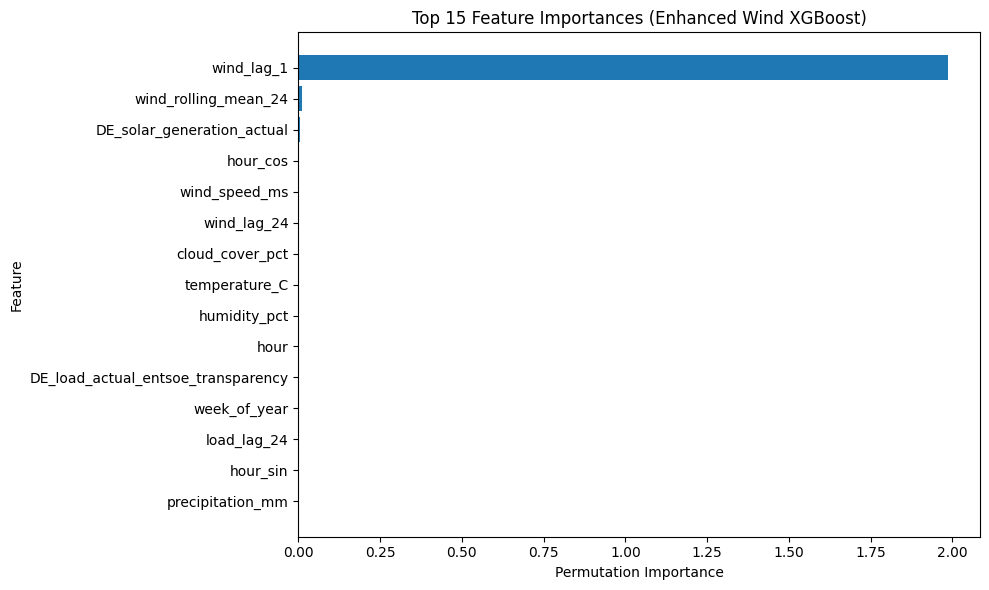

In [20]:
import matplotlib.pyplot as plt

top_n = 15

plot_df = (
    importance_df
    .head(top_n)
    .sort_values('Importance')
)

plt.figure(figsize=(10, 6))
plt.barh(
    plot_df['Feature'],
    plot_df['Importance']
)

plt.title('Top 15 Feature Importances (Enhanced Wind XGBoost)')
plt.xlabel('Permutation Importance')
plt.ylabel('Feature')

plt.tight_layout()
plt.show()

## Interpretation of Permutation Importance Results

The permutation importance analysis reveals that wind generation forecasting is overwhelmingly driven by historical wind generation behaviour.

The most important feature by a substantial margin is:

- wind_lag_1

This feature alone contributes significantly more predictive information than any other variable in the dataset. The next most influential features are:

- wind_rolling_mean_24
- DE_solar_generation_actual
- hour_cos
- wind_speed_ms
- wind_lag_24

However, their importance values are several orders of magnitude smaller than that of wind_lag_1.

These findings indicate that wind generation exhibits strong temporal persistence, meaning that the wind power output observed in the previous hour is highly informative for predicting future output. The dramatic improvement in forecasting performance after introducing wind-specific lag features confirms that historical generation information is essential for accurate short-term wind forecasting.

The results also highlight an important distinction between solar and wind forecasting. While solar generation was primarily influenced by temporal and meteorological variables such as hour of day and weather conditions, wind generation was dominated by its own recent history.

Overall, the analysis demonstrates that feature engineering contributed far more to forecasting accuracy than increasing model complexity, with wind-specific lag features enabling all machine learning models to achieve R² values exceeding 0.99.

## Sensitivity Test: Wind Forecasting Without `wind_lag_1`

The permutation importance analysis showed that `wind_lag_1` overwhelmingly dominates the Enhanced XGBoost model. This indicates that the model relies heavily on wind generation from the previous hour.

To test whether the model is learning broader wind generation patterns rather than depending almost entirely on short-term persistence, a sensitivity experiment is performed.

In this experiment, `wind_lag_1` is removed from the feature set, while other wind-related features such as `wind_lag_24`, `wind_lag_168`, and `wind_rolling_mean_24` are retained.

The objective is to evaluate how much forecasting performance decreases when the most dominant short-term lag feature is excluded.

In [21]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Remove the dominant one-hour wind lag feature
X_no_wind_lag_1 = X.drop(columns=['wind_lag_1'])

# Chronological split
split_index = int(len(df) * 0.8)

X_train_no_lag1 = X_no_wind_lag_1.iloc[:split_index]
X_test_no_lag1 = X_no_wind_lag_1.iloc[split_index:]

y_train_no_lag1 = y.iloc[:split_index]
y_test_no_lag1 = y.iloc[split_index:]

# Train XGBoost without wind_lag_1
xgb_no_lag1 = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    objective='reg:squarederror',
    random_state=42,
    n_jobs=-1
)

xgb_no_lag1.fit(X_train_no_lag1, y_train_no_lag1)

# Predictions
y_pred_no_lag1 = xgb_no_lag1.predict(X_test_no_lag1)

# Metrics
no_lag1_mae = mean_absolute_error(y_test_no_lag1, y_pred_no_lag1)
no_lag1_rmse = np.sqrt(mean_squared_error(y_test_no_lag1, y_pred_no_lag1))
no_lag1_r2 = r2_score(y_test_no_lag1, y_pred_no_lag1)

print("XGBoost without wind_lag_1 MAE :", round(no_lag1_mae, 4))
print("XGBoost without wind_lag_1 RMSE:", round(no_lag1_rmse, 4))
print("XGBoost without wind_lag_1 R²  :", round(no_lag1_r2, 4))

XGBoost without wind_lag_1 MAE : 3296.2981
XGBoost without wind_lag_1 RMSE: 4306.1901
XGBoost without wind_lag_1 R²  : 0.8316


## Sensitivity Analysis: Removing `wind_lag_1`

To evaluate the influence of the most dominant predictor, the Enhanced XGBoost model was retrained after removing the `wind_lag_1` feature.

| Model | MAE | RMSE | R² |
|----------|----------:|----------:|----------:|
| Enhanced XGBoost | 786.76 | 1038.13 | 0.9902 |
| XGBoost without `wind_lag_1` | 3296.30 | 4306.19 | 0.8316 |

The removal of `wind_lag_1` resulted in a substantial reduction in forecasting performance. MAE increased by more than four times, while the R² score decreased from 0.9902 to 0.8316.

These results confirm that wind generation exhibits strong short-term temporal persistence and that the previous hour's wind generation is the single most informative predictor of future output.

However, the model continued to achieve an R² score exceeding 0.83 even without `wind_lag_1`, indicating that weather variables, temporal features, and longer-term wind history still provide meaningful predictive information.

This sensitivity analysis demonstrates both the importance of short-term persistence and the value of broader feature engineering for wind generation forecasting.

## Model Persistence and Reproducibility

To support future analysis, carbon impact assessment, and dashboard development, the final wind generation forecasting model and its associated metadata are exported.

The following artifacts are saved:

- Trained Enhanced XGBoost model
- Feature names used during training
- Final evaluation metrics
- Processed wind forecasting dataset

Persisting these artifacts ensures reproducibility and enables future notebooks to load the trained model without requiring retraining.

In [22]:
import os

os.makedirs(
    "../models/wind_generation",
    exist_ok=True
)

print("Folder ready.")

Folder ready.


In [23]:
import joblib

joblib.dump(
    xgb_model_wind,
    "../models/wind_generation/wind_xgboost_enhanced.pkl"
)

print("Wind model saved.")

Wind model saved.


In [24]:
feature_names = X.columns.tolist()

joblib.dump(
    feature_names,
    "../models/wind_generation/feature_names.pkl"
)

print("Feature names saved.")

Feature names saved.


In [25]:
wind_metrics = {
    "MAE": 786.7631,
    "RMSE": 1038.1251,
    "R2": 0.9902
}

joblib.dump(
    wind_metrics,
    "../models/wind_generation/model_metrics.pkl"
)

print("Metrics saved.")

Metrics saved.


In [26]:
X.to_csv(
    "../data/processed/wind_features.csv",
    index=False
)

y.to_csv(
    "../data/processed/wind_target.csv",
    index=False
)

print("Wind dataset saved.")

Wind dataset saved.


In [27]:
import os

print(
    os.listdir("../models/wind_generation")
)

['feature_names.pkl', 'model_metrics.pkl', 'wind_xgboost_enhanced.pkl']


## Saving Wind Forecasting Artifacts

The final wind forecasting metrics and model comparison results are saved for future evaluation, reporting, and dashboard development.

In [1]:
import pandas as pd

wind_model_comparison = pd.DataFrame({
    "Model": [
        "Baseline",
        "Linear Regression",
        "Random Forest",
        "XGBoost",
        "Enhanced Linear Regression",
        "Enhanced Random Forest",
        "Enhanced XGBoost"
    ],
    "MAE": [
        8334.12,
        4050.68,
        4021.28,
        4364.69,
        753.89,
        752.84,
        786.76
    ],
    "RMSE": [
        11049.17,
        5223.40,
        5238.75,
        5729.31,
        1035.24,
        1040.98,
        1038.13
    ],
    "R2": [
        -0.1096,
        0.7520,
        0.7506,
        0.7017,
        0.9903,
        0.9902,
        0.9902
    ]
})

wind_model_comparison.to_csv(
    "../models/wind_generation/wind_model_comparison.csv",
    index=False
)

print("Wind model comparison saved.")

Wind model comparison saved.
